In [1]:
%run data_prep.ipynb 

In [2]:
df.head()

,status,goal,pledged,funded percentage,backers,levels,updates,comments,duration,category_Comics,...,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,funded_month
0,successful,10500.0,11545.0,1.099524,66,7,10,2,30.00,0,...,0,0,0,0,0,0,0,0,0,8
1,failed,4000.0,20.0,0.005000,2,5,6,0,47.18,0,...,0,0,0,0,0,0,0,0,0,8
3,successful,6000.0,6535.0,1.089167,100,13,4,0,32.22,0,...,0,0,0,0,0,0,0,0,0,4
4,failed,3500.0,0.0,0.000000,0,6,2,0,30.00,0,...,0,0,0,0,0,0,0,0,0,6
5,successful,3500.0,3582.0,1.023331,39,7,8,0,21.43,0,...,0,0,0,0,0,0,0,0,0,6


In [3]:
X_train

,goal,levels,updates,comments,duration,category_Comics,category_Dance,category_Design,category_Fashion,category_Film & Video,...,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,funded_month
37370,6000.00,10,0,0,30.00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
7739,7500.00,8,6,3,31.00,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,9
6232,1111.99,6,20,1,60.04,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,11
10182,9000.00,9,2,0,43.96,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
11157,2400.00,9,0,0,59.96,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15267,30000.00,7,32,2,35.00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
6895,4500.00,11,12,0,30.51,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
21348,450.00,11,6,3,30.00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
28551,1500.00,20,0,0,30.00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [4]:
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder  
from sklearn.ensemble import RandomForestClassifier as Ran

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rf = Ran(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred))


Baseline Accuracy: 0.8446914606274672


In [5]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score


cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


Confusion Matrix:
 [[3489  797]
 [ 698 4642]]
Precision: 0.8444839968710477
Recall: 0.8446914606274672
F1 Score: 0.8444973523038587


In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],        
    'max_depth': [None, 5, 10, 20],        
    'min_samples_split': [2, 5, 10],       
    'min_samples_leaf': [1, 2, 4],         
    'max_features': ['sqrt', 'log2']       
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.8450033157055318
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.8450033157055318


In [7]:
best_rf = grid.best_estimator_
best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print("Test Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Test Accuracy: 0.8514440058175774
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      4286
           1       0.86      0.88      0.87      5340

    accuracy                           0.85      9626
   macro avg       0.85      0.85      0.85      9626
weighted avg       0.85      0.85      0.85      9626



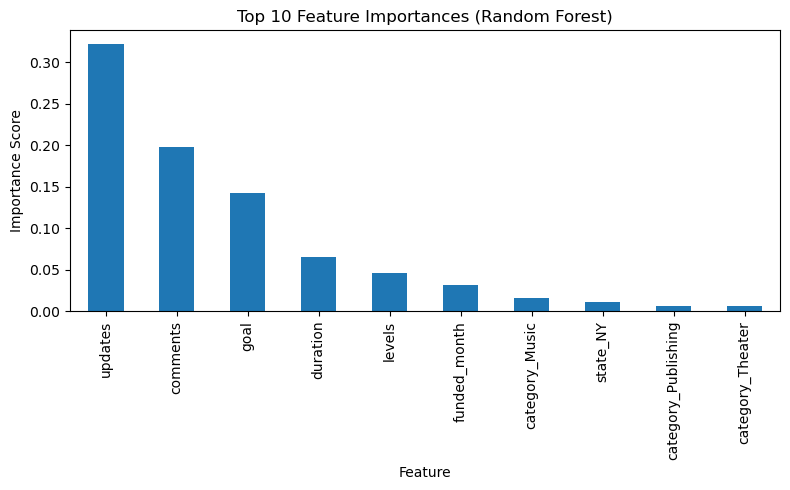

In [8]:
import matplotlib.pyplot as plt

best_rf = grid.best_estimator_
importances = pd.Series(best_rf.feature_importances_, index=X.columns)

top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top_features.plot(kind='bar')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()


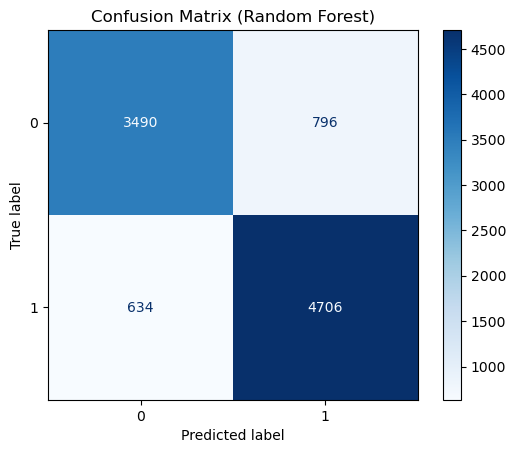

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_best = best_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Random Forest)")
plt.show()

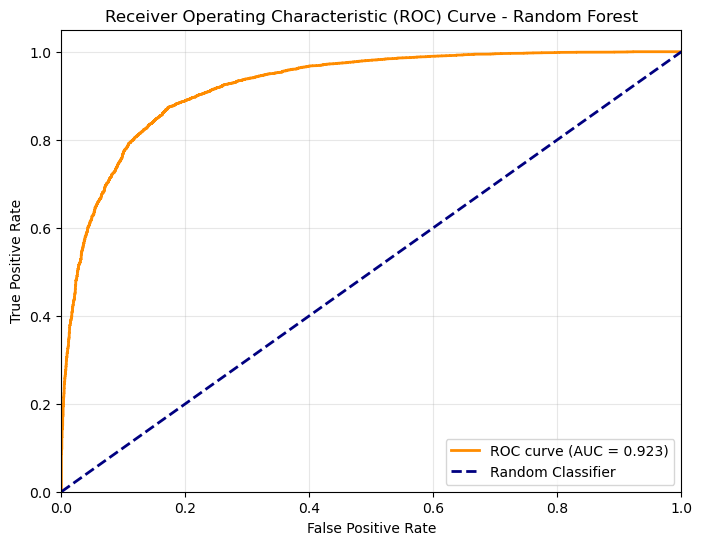

ROC AUC Score: 0.923


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"ROC AUC Score: {roc_auc:.3f}")

In [11]:
# import pickle
# with open('random_forest_model.pkl', 'wb') as f:
#     pickle.dump(best_rf, f) 